In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['figure.dpi'] = 110

sns.set_theme(style='whitegrid')

In [74]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [75]:
import seaborn as sns

df=sns.load_dataset('geyser')

print('Shape', df.shape)

df.head()

Shape (272, 3)


,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long


LOAD and INSPECT

In [76]:
print("\nColumns:", df.columns)
df.head()    # first 5 rows
df.tail()    # last 5 rows



Columns: Index(['duration', 'waiting', 'kind'], dtype='object')


,duration,waiting,kind
267,4.117,81,long
268,2.150,46,short
269,4.417,90,long
270,1.817,46,short
271,4.467,74,long


In [77]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duration  272 non-null    float64
 1   waiting   272 non-null    int64  
 2   kind      272 non-null    object 
dtypes: float64(1), int64(1), object(1)
memory usage: 6.5+ KB


,duration,waiting
count,272.000000,272.000000
mean,3.487783,70.897059
std,1.141371,13.594974
min,1.600000,43.000000
25%,2.162750,58.000000
50%,4.000000,76.000000
75%,4.454250,82.000000
max,5.100000,96.000000


In [78]:
# Check Missing Values
df.isnull().sum()

#Unique Values (for categorical column)
print(df['kind'].unique())
print(df['kind'].value_counts())



['long' 'short']
kind
long     172
short    100
Name: count, dtype: int64


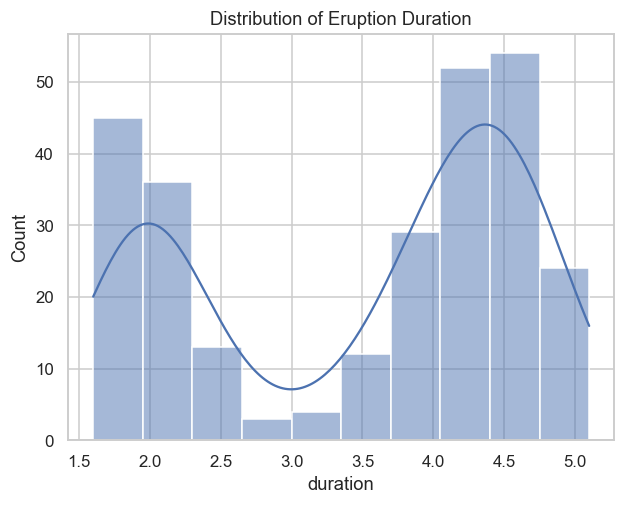

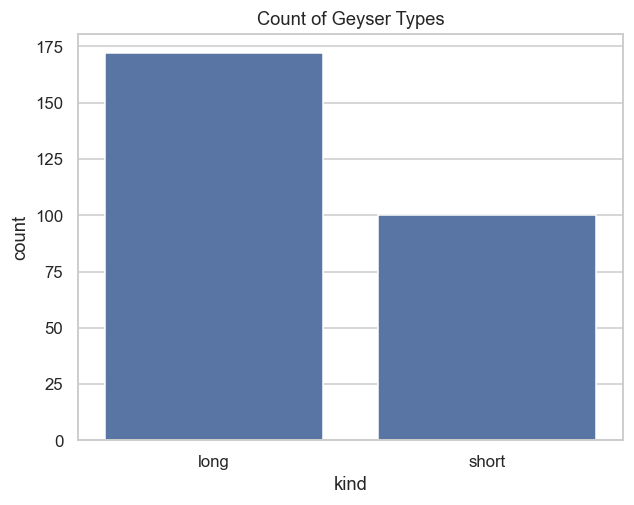

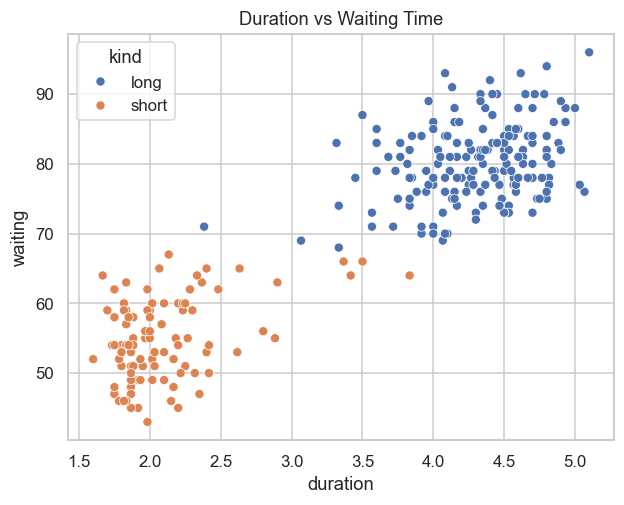

In [79]:
#Quick Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of eruption duration
sns.histplot(df['duration'], kde=True)
plt.title("Distribution of Eruption Duration")
plt.show()

# Count of geyser types
sns.countplot(x='kind', data=df)
plt.title("Count of Geyser Types")
plt.show()

# Relationship between duration & waiting time
sns.scatterplot(x='duration', y='waiting', hue='kind', data=df)
plt.title("Duration vs Waiting Time")
plt.show()

clean and prepare

In [80]:
df.isnull().sum()

# Example: drop missing rows
df = df.dropna()

# OR fill missing values
df['duration'] = df['duration'].fillna(df['duration'].mean())


In [81]:
df = df.drop_duplicates()
df.dtypes

# Example: convert to numeric
df['duration'] = df['duration'].astype(float)


<Axes: xlabel='eruption_duration'>

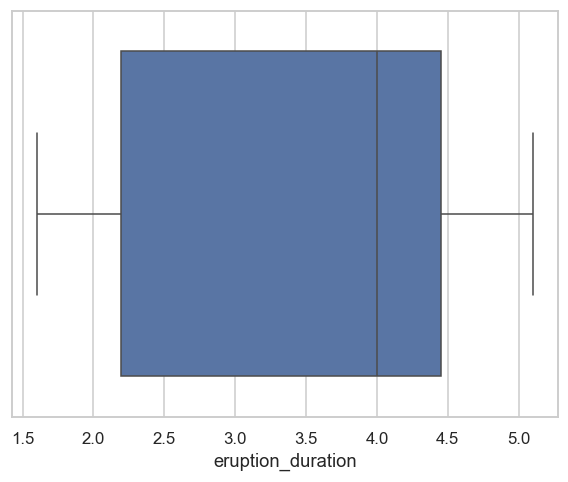

In [82]:
df.rename(columns={'duration': 'eruption_duration'}, inplace=True)

# Handle Outliers (extreme values)
sns.boxplot(x=df['eruption_duration'])


In [83]:
#  Create New Columns (Feature Engineering)
df['waiting_group'] = df['waiting'].apply(
    lambda x: 'short_wait' if x < 60 else 'long_wait'
)


In [84]:
# Standardize Values
df['kind'] = df['kind'].str.lower()


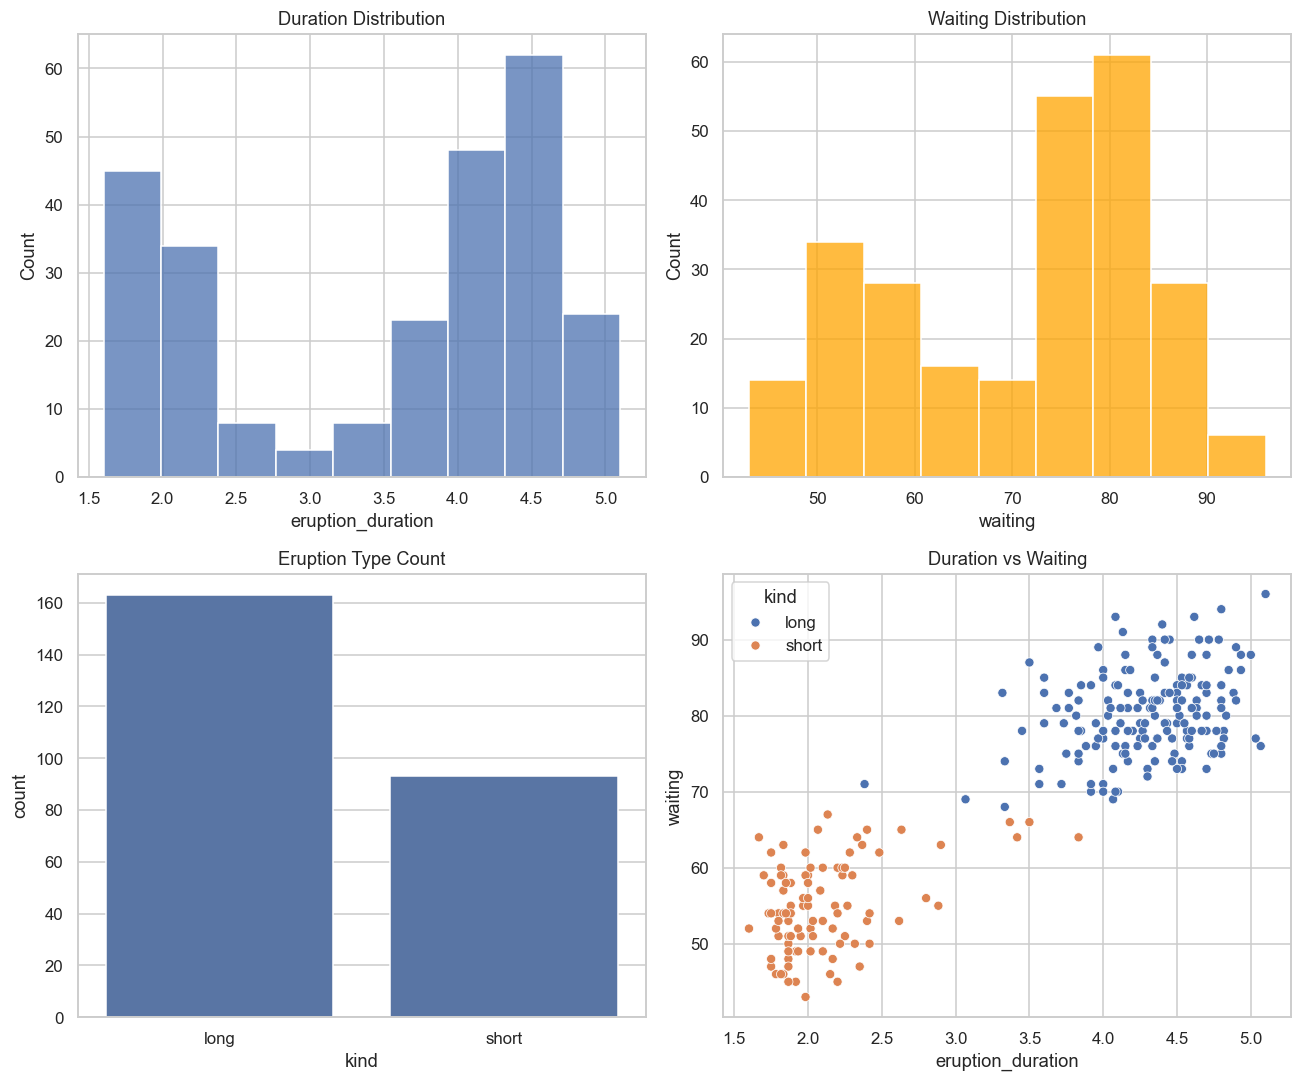

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df['eruption_duration'], ax=axes[0, 0])
axes[0, 0].set_title("Duration Distribution")

sns.histplot(df['waiting'], ax=axes[0, 1], color='orange')
axes[0, 1].set_title("Waiting Distribution")

sns.countplot(x='kind', data=df, ax=axes[1, 0])
axes[1, 0].set_title("Eruption Type Count")

sns.scatterplot(x='eruption_duration', y='waiting', hue='kind', data=df, ax=axes[1, 1])
axes[1, 1].set_title("Duration vs Waiting")

plt.tight_layout()
plt.savefig('geyser_1_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 704x528 with 0 Axes>

C:\Users\SH173SF\AppData\Local\Temp\ipykernel_9048\704526422.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='waiting', index='kind', columns='duration_group', aggfunc='mean')


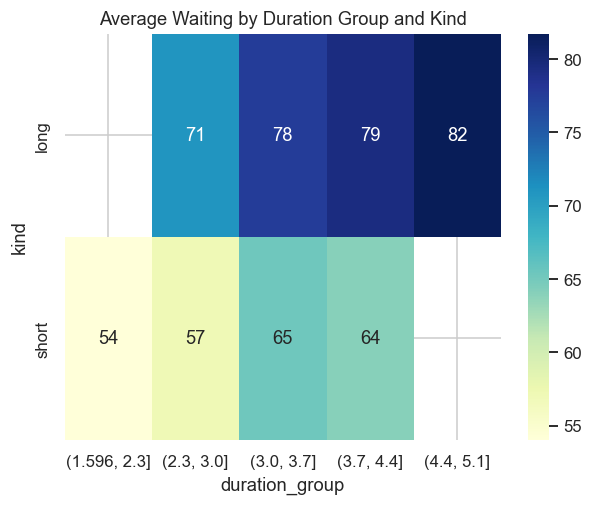

In [92]:
# Create duration groups
df['duration_group'] = pd.cut(df['eruption_duration'], bins=5)

pivot = df.pivot_table(values='waiting', index='kind', columns='duration_group', aggfunc='mean')

sns.heatmap(pivot, annot=True, cmap='YlGnBu')
plt.title("Average Waiting by Duration Group and Kind")
plt.savefig('geyser_2_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()